# ENGR 240: Parameters in Roots Problems - Michaelis-Menten Kinetics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WCC-Engineering/ENGR240-Demos-and-Worksheets/blob/main/Week%203/Worksheet%203-2_template.ipynb)

## Introduction

In many engineering applications, we encounter nonlinear equations that need to be solved for different parameter values. This worksheet focuses on how to handle changing parameters when using root-finding methods and explores the concept of "residuals" in numerical approximations.

### Learning Objectives
- Implement parameter-passing techniques in root-finding methods
- Compare Newton-Raphson method and `scipy.optimize.root_scalar` with Brentq method for parametric roots problems
- Understand and calculate residuals in numerical approximations
- Visualize substrate concentration profiles using the Michaelis-Menten model
- Gain programming practice with functions, loops, and arrays

### Mathematical Background

The **Michaelis-Menten model** describes the kinetics of enzyme-mediated reactions. It is represented by the following equation:

$$S = S_0 - v_m t + k_s \ln\left(\frac{S_0}{S}\right)$$

where:
- $S$ = substrate concentration (mol/L)
- $S_0$ = initial substrate concentration (mol/L) at t = 0
- $v_m$ = maximum uptake rate (mol/L/d)
- $k_s$ = half saturation constant (mol/L)
- $t$ = time (days)

For this worksheet, we need to solve for $S$ given specific values of $S_0$, $v_m$, $k_s$, and $t$. Since $S$ appears on both sides of the equation, we can't solve for it directly. Instead, we need to rearrange the equation to find the roots:

$$f(S) = S - S_0 + v_m t - k_s \ln\left(\frac{S_0}{S}\right) = 0$$

## Setup and Imports

First, let's import the necessary libraries:

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
import time  # for timing comparison

## Newton-Raphson Method with Parameters

The Newton-Raphson method is an iterative approach to finding roots. We've previously studied the basic implementation. The method uses the formula:

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

When working with parameters, we need to modify our implementation to accept additional parameter values.

### Implementation with Parameter Passing

Let's define our function and its derivative for the Michaelis-Menten model:

In [40]:
def mm_function(S, S0, vm, ks, t):
    """
    Michaelis-Menten function whose root we seek.

    Parameters:
    -----------
    S : float
        Substrate concentration (mol/L)
    S0 : float
        Initial substrate concentration (mol/L)
    vm : float
        Maximum uptake rate (mol/L/d)
    ks : float
        Half saturation constant (mol/L)
    t : float
        Time (days)

    Returns:
    --------
    float : Function value at S
    """
    return S - S0 + vm * t - ks * np.log(S0 / S)

### Task 1: Derive and Implement the Derivative Function

Derive the derivative of the Michaelis-Menten function with respect to S:

$$\frac{d}{dS}\left[S - S_0 + v_m t - k_s \ln\left(\frac{S_0}{S}\right)\right]$$

Implement your derived formula in the `mm_derivative` function below. Test your implementation by running the Newton-Raphson method.

In [41]:
# NOTE: You will need to derive and implement the derivative function.
# Remove the next line and add your implementation for mm_derivative

"""
STUDENT ACTIVITY:
1. Derive the derivative of mm_function with respect to S
2. Implement the derivative function below
"""

def mm_derivative(S, S0, vm, ks, t):
    """
    Derivative of the Michaelis-Menten function with respect to S.

    Parameters:
    -----------
    (Same as mm_function)

    Returns:
    --------
    float : Derivative value at S
    """
    return 1 + ks/S

Now let's implement the Newton-Raphson method with parameter passing:

In [42]:
def newton_raphson(func, dfunc, x0, tol=1e-8, max_iter=100, **params):
    """
    Newton-Raphson method to find a root of a function.

    Parameters:
    -----------
    func : function
        Function to find root of
    dfunc : function
        Derivative of the function
    x0 : float
        Initial guess
    tol : float
        Error tolerance
    max_iter : int
        Maximum number of iterations
    **params : dict
        Additional parameters to pass to the function

    Returns:
    --------
    tuple : (root, iterations, error, residual)
    """
    x = x0
    error = float('inf')
    iter_count = 0

    while error > tol and iter_count < max_iter:
        f_x = func(x, **params)
        df_x = dfunc(x, **params)

        if df_x == 0:
            raise ValueError("Derivative is zero. Cannot continue.")

        x_new = x - f_x / df_x

        # Calculate relative error
        error = abs((x_new - x) / x_new) if x_new != 0 else abs(x_new - x)

        x = x_new
        iter_count += 1

    # Calculate residual - the function value at our solution
    residual = abs(func(x, **params))

    return x, iter_count, error, residual

## Using root_scalar with Brentq Method

SciPy's `root_scalar` function with the Brentq method is a powerful tool for finding roots of nonlinear equations. The Brentq method is a robust bracketing method that combines the reliability of bisection with the efficiency of inverse quadratic interpolation.

### How the Brentq Method Works

The Brentq method is a bracketing method, which means it requires an initial interval [a, b] that contains the root (i.e., f(a) and f(b) have opposite signs). It then iteratively narrows down this interval until a root is found within the specified tolerance. The key advantages of Brentq are:

1. It's guaranteed to converge if there's a root in the initial bracket
2. It combines the reliability of bisection with faster convergence strategies
3. It doesn't require derivative information

### Basic Syntax and Parameters

The basic syntax of `root_scalar` with the Brentq method is:

```python
result = optimize.root_scalar(func, method='brentq', bracket=[a, b], xtol=1e-8, ...)
```

Where:
- `func` is the function to find the roots of
- `method='brentq'` specifies we want to use the Brentq method
- `bracket=[a, b]` is the interval containing the root
- `xtol` is the relative error tolerance

#### Algorithm Parameters vs. Function Parameters

It's important to distinguish between two types of parameters:

1. **Algorithm parameters** - These control how `root_scalar` operates, such as:
   ```python
   # Example of adjusting algorithm parameters
   result = optimize.root_scalar(func, method='brentq', bracket=[a, b], xtol=1e-10, maxiter=1000, full_output=True)
   ```
   
2. **Function parameters** - These are passed to your function to evaluate it (what this worksheet focuses on):
   ```python
   # Example of passing parameters to your function using a lambda
   def my_func(x, a, b, c):
       return x**2 + a*x + b - c
       
   # These parameters (5, 3, 10) are passed to my_func as a, b, c via the lambda function
   result = optimize.root_scalar(lambda x: my_func(x, 5, 3, 10), method='brentq', bracket=[0, 5])
   ```

#### When to Use Different Parameter Passing Approaches

For this worksheet, we'll explore parameter passing strategies that provide flexibility and maintainability. Lambda functions are particularly useful with `root_scalar` because they allow you to:

1. **Use keyword arguments**: Lambda functions make it easy to use keyword arguments (`S0=`, `vm=`, etc.) which are more readable.

2. **Avoid parameter order dependency**: With lambdas, you can manage the parameter order explicitly.

3. **Handle changing parameters in loops**: When solving for many different parameter combinations (like our time loop), lambdas make it easy to update only the parameters that change.

4. **Improve readability**: Lambda functions make the code's intent clearer, especially when only some parameters change while others remain fixed.

Let's see how to implement an approach using `root_scalar` with the Brentq method:

In [43]:
def solve_with_brentq(t, S0, vm, ks, bracket):
    """
    Solve the Michaelis-Menten equation using scipy.optimize.root_scalar with Brentq method.

    Parameters:
    -----------
    t : float
        Time (days)
    S0, vm, ks : float
        Model parameters
    bracket : list or tuple
        Bracket [a, b] containing the root

    Returns:
    --------
    tuple : (root, residual)
    """
    # Lambda function with parameters
    f = lambda S: mm_function(S, S0=S0, vm=vm, ks=ks, t=t)

    # Solve using root_scalar with Brentq method
    result = optimize.root_scalar(f, method='brentq', bracket=bracket)
    root = result.root

    # Calculate residual
    residual = abs(f(root))

    return root, residual

## Problem Setup

Let's set up our problem with the following parameters:
- Initial substrate concentration (S0) = 10 mol/L
- Maximum uptake rate (vm) = 0.5 mol/L/d
- Half saturation constant (ks) = 2 mol/L
- Time range from 0 to 50 days in steps of 5 days
- Use a stopping tolerance of 1e-8 for both methods

In [44]:
# Set parameters
S0 = 10.0  # mol/L
vm = 0.5   # mol/L/d
ks = 2.0   # mol/L
t_values = np.arange(0, 51, 5)  # days

# Initial guess for S
initial_guess = 0.0001

# Define parameter dictionaries for both methods add **newton_params to newtonraphson function call
# add a single value of t with newton_params['t'] = t where t is the current value
newton_params = {'S0': S0, 'vm': vm, 'ks': ks}
brentq_bracket = [0.0001, 10.01]  # Bracket for Brentq method

## Calculating S vs t and Residuals

Now, let's calculate S vs t and the associated residuals for both methods.

### Task 2: Implement Parameter Looping

For this task, you need to:

1. Create arrays to store the results
2. Loop through each time value
3. Call both root-finding methods with the appropriate parameters
4. Calculate and store the residuals
5. Compare the computation times

Start by setting up empty arrays to store your results and then implement a loop to call both root-finding methods for each time value. Your implementation should follow this general structure:

```python
# Arrays to store results
# Your code here

# Loop through each time value
# Your code here

```

In [45]:
s_brentq = []
res_brentq = []
s_newton = []
res_newton = []


for t in t_values:
  #Brentq returns (root, residual)
  root, res = solve_with_brentq(t, S0, vm, ks, brentq_bracket)
  s_brentq.append(root)
  res_brentq.append(res)

  #Newton returns (x, iter_count, error, residual)
  newton_params['t'] = t
  root, _,_, res = newton_raphson(mm_function, mm_derivative, initial_guess, tol=1e-8, max_iter=100, **newton_params)
  s_newton.append(root)
  res_newton.append(res)

print("s_brentq\tres_brentq\ts_newton\tres_newton")
for i in range(0, len(t_values)-1):
  print(f"{s_brentq[i]:.4e},\t{res_brentq[i]:.4e},\t{s_newton[i]:.4e},\t{res_newton[i]:.4e}")



s_brentq	res_brentq	s_newton	res_newton
1.0000e+01,	0.0000e+00,	1.0000e+01,	0.0000e+00
7.9571e+00,	3.8858e-16,	7.9571e+00,	4.9960e-16
6.0162e+00,	0.0000e+00,	6.0162e+00,	0.0000e+00
4.2237e+00,	2.2204e-16,	4.2237e+00,	2.2204e-16
2.6534e+00,	2.1316e-14,	2.6534e+00,	8.8818e-16
1.4133e+00,	4.4409e-16,	1.4133e+00,	4.4409e-16
6.0621e-01,	8.8818e-16,	6.0621e-01,	1.7764e-15
2.1157e-01,	2.6645e-14,	2.1157e-01,	0.0000e+00
6.5218e-02,	7.1054e-14,	6.5218e-02,	0.0000e+00
1.9121e-02,	2.4230e-12,	1.9121e-02,	0.0000e+00


## Visualizing the Results

### Task 3: Create Visualizations

Create plots to visualize your results. You should:

1. Plot S vs t for both methods
2. Plot the residuals vs t for both methods

Your implementation should produce informative plots with appropriate labels, titles, and legends.

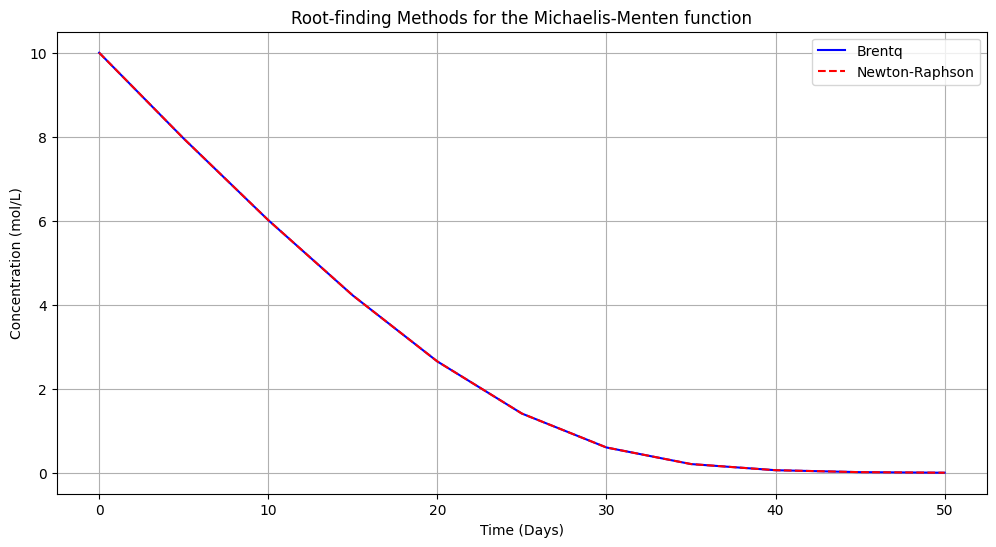

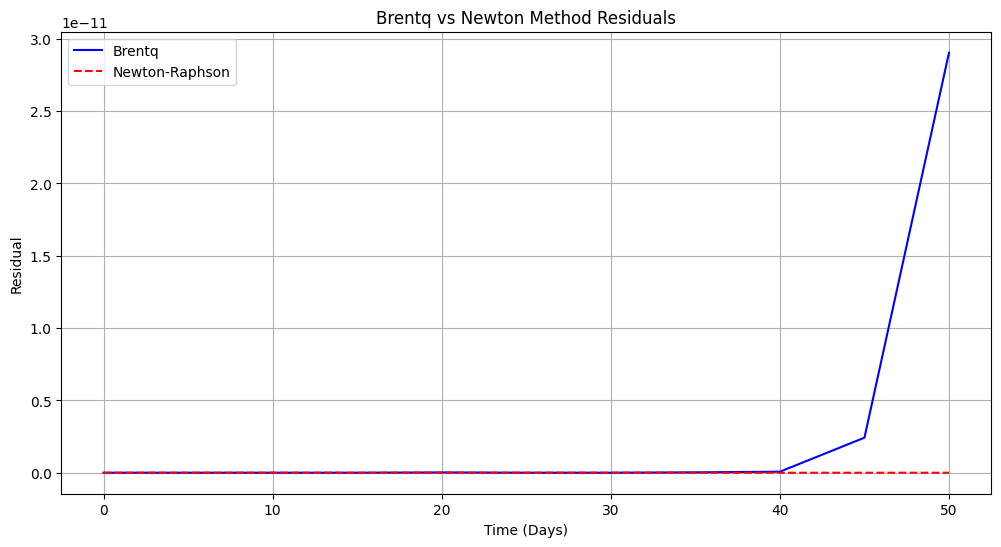

In [46]:
from matplotlib.lines import lineStyles
plt.figure(figsize=(12,6))
plt.plot(t_values, s_brentq, label="Brentq", color="blue")
plt.plot(t_values, s_newton, label="Newton-Raphson", color="red", linestyle="dashed")
plt.xlabel("Time (Days)")
plt.ylabel("Concentration (mol/L)")
plt.legend()
plt.grid()
plt.title("Root-finding Methods for the Michaelis-Menten function")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(t_values, res_brentq,label="Brentq", color="blue")
plt.plot(t_values, res_newton, label="Newton-Raphson", color="red", linestyle="dashed")
plt.xlabel("Time (Days)")
plt.ylabel("Residual")
plt.legend()
plt.grid()
plt.title("Brentq vs Newton Method Residuals")
plt.show()

## Discussion Questions

After completing the implementation and visualization tasks, consider the following questions:

1. How do the two methods compare in terms of:
   - Accuracy (residuals)
   - Ease of implementation

In terms of accuracy, the Newton-Raphson's method outperforms Brentq as t approaches 50 days, where the residuals of Brentq shoot up and Newton-Raphson's model stays near 0.

As for ease of implementation, I believe that Brentq method is easier as it is an accessible tool for general applications that guaratees convergence for a root inside the bracket and doesn't require a derivative like Newton-Rahpson's method.


2. How would you modify the code to handle multiple parameter variations (not just time) efficiently?

You could used lambda functions with a parameterized input; for one function you could pass an argument for the function to be evaluated in terms of x or t, or S.

## Conclusion

In this worksheet, we've explored how to handle parameters in root-finding problems using the Newton-Raphson method and `scipy.optimize.root_scalar` with the Brentq method. We've also examined the concept of residuals in numerical approximations and compared the efficiency and accuracy of different approaches.

Key takeaways:
1. Parameter passing in numerical methods can be handled through function arguments or keyword arguments
2. Lambda functions provide a clean way to parameterize functions for `root_scalar`
3. Residuals help us understand the accuracy of our numerical solutions
4. The Newton-Raphson method requires derivative information but may converge faster when derivatives are simple
5. The Brentq method is a robust bracketing method that doesn't require derivatives but needs a bracket containing the root
6. For complex problems, specialized libraries like SciPy offer robust and efficient solutions
